
==== CE: annual seasonality assessment ====
Amplitude (cm):        0.8563
Peak-to-trough (cm):   1.7125
Peak date (UTC):       2024-11-01
Var reduction from season terms vs (intercept+trend): 4.17%

==== WC: annual seasonality assessment ====
Amplitude (cm):        1.1914
Peak-to-trough (cm):   2.3829
Peak date (UTC):       2023-09-28
Var reduction from season terms vs (intercept+trend): 39.29%

==== WE: annual seasonality assessment ====
Amplitude (cm):        2.5315
Peak-to-trough (cm):   5.0629
Peak date (UTC):       2023-09-10
Var reduction from season terms vs (intercept+trend): 19.43%


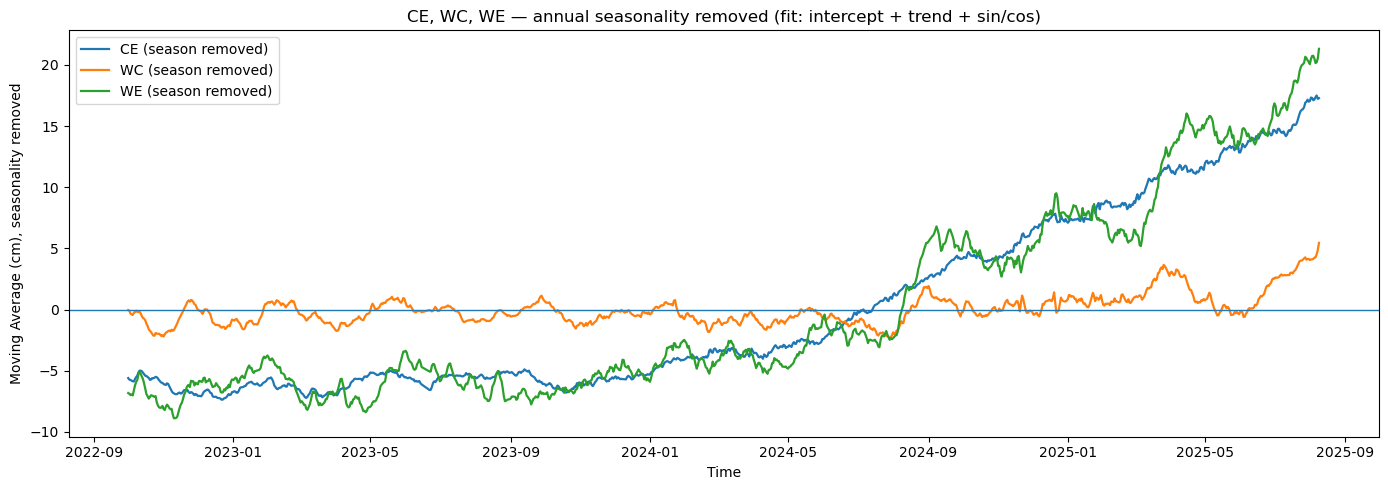

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User edits
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR  # rad/day

BASELINES = [
    ("CE", CE_FILE),
    ("WC", WC_FILE),
    ("WE", WE_FILE),
]

# -----------------------------
# Load baseline, daily resample
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)

    # Expect columns: "Record Time" and "Moving Average (cm)"
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    # Drop first N days relative to that file's start (startup transient)
    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

# -----------------------------
# Fit annual seasonality (sin/cos) + intercept + linear trend
# Returns: season(t), y_deseasoned, diagnostics
# -----------------------------
def fit_and_remove_annual_season(y_series, t0_common):
    y = y_series.to_numpy()
    t_days = (y_series.index - t0_common).total_seconds() / 86400.0

    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    # Full model: y = a + m*t + c*sin + d*cos
    A_full = np.column_stack([np.ones_like(t_days), t_days, sin_t, cos_t])
    x_full, *_ = np.linalg.lstsq(A_full, y, rcond=None)
    a, m, c, d = x_full

    season = c * sin_t + d * cos_t
    y_deseason = y - season

    # Reduced model (no season terms): y = a + m*t
    A_red = np.column_stack([np.ones_like(t_days), t_days])
    x_red, *_ = np.linalg.lstsq(A_red, y, rcond=None)
    yhat_red = A_red @ x_red
    yhat_full = A_full @ x_full

    sse_red = float(np.sum((y - yhat_red) ** 2))
    sse_full = float(np.sum((y - yhat_full) ** 2))
    seasonal_var_reduction = 100.0 * (1.0 - (sse_full / sse_red)) if sse_red > 0 else np.nan

    amp = float(np.sqrt(c * c + d * d))  # seasonal amplitude in cm
    # Peak timing (max of season) in days from t0_common
    peak_idx = int(np.argmax(season))
    peak_date = y_series.index[peak_idx]

    diag = {
        "a": float(a), "m": float(m), "c": float(c), "d": float(d),
        "amp_cm": amp,
        "peak_to_trough_cm": 2.0 * amp,
        "peak_date_utc": peak_date,
        "seasonal_var_reduction_pct": seasonal_var_reduction,
    }
    return season, pd.Series(y_deseason, index=y_series.index, name=y_series.name), diag

# ============================================================
# MAIN
# ============================================================
series = {}
for name, path in BASELINES:
    series[name] = load_baseline_daily_ma(path, name)

# Align to common daily window (only dates where all 3 exist)
df = pd.concat([series[n] for n, _ in BASELINES], axis=1).dropna()
t0_common = df.index[0]

deseason = pd.DataFrame(index=df.index)
diagnostics = {}

for name, _ in BASELINES:
    season, y_deseason, diag = fit_and_remove_annual_season(df[name], t0_common)
    deseason[name] = y_deseason
    diagnostics[name] = diag

    print(f"\n==== {name}: annual seasonality assessment ====")
    print(f"Amplitude (cm):        {diag['amp_cm']:.4f}")
    print(f"Peak-to-trough (cm):   {diag['peak_to_trough_cm']:.4f}")
    print(f"Peak date (UTC):       {diag['peak_date_utc'].strftime('%Y-%m-%d')}")
    print(f"Var reduction from season terms vs (intercept+trend): {diag['seasonal_var_reduction_pct']:.2f}%")

# ============================================================
# PLOT: all 3 seasonality-removed baselines on one figure
# ============================================================
plt.figure(figsize=(14, 5))
for name, _ in BASELINES:
    plt.plot(deseason.index, deseason[name]-deseason[name].mean(), lw=1.6, label=f"{name} (season removed)")

plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("Moving Average (cm), seasonality removed")
plt.title("CE, WC, WE — annual seasonality removed (fit: intercept + trend + sin/cos)")
plt.legend()
plt.tight_layout()
plt.show()


In [56]:
we

Record Time
2022-09-30 00:00:00+00:00    326019.800925
2022-10-01 00:00:00+00:00    326019.241227
2022-10-02 00:00:00+00:00    326019.164519
2022-10-03 00:00:00+00:00    326019.046257
2022-10-04 00:00:00+00:00    326019.082427
                                 ...      
2025-08-20 00:00:00+00:00    326047.931077
2025-08-21 00:00:00+00:00    326048.179871
2025-08-22 00:00:00+00:00    326048.655292
2025-08-23 00:00:00+00:00    326049.180988
2025-08-24 00:00:00+00:00    326049.648884
Freq: D, Name: WE, Length: 1060, dtype: float64


==== CE annual seasonality ====
Amplitude: 0.8563 cm (peak-to-trough 1.7125 cm)

==== WC annual seasonality ====
Amplitude: 1.1914 cm (peak-to-trough 2.3829 cm)

==== WE annual seasonality ====
Amplitude: 2.5315 cm (peak-to-trough 5.0629 cm)

==== CM1 summary (from seasonality-removed data) ====
Variance explained by CM1: 98.4%
CM1 loadings: {'CE': 0.6755356244794007, 'WC': 0.08175280605392397, 'WE': 0.7327810715087663}


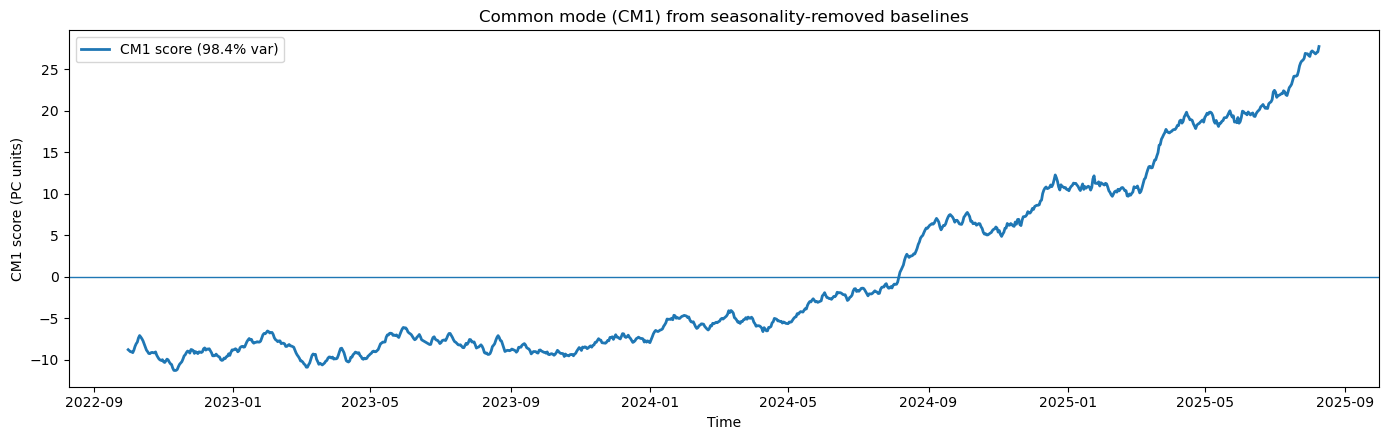

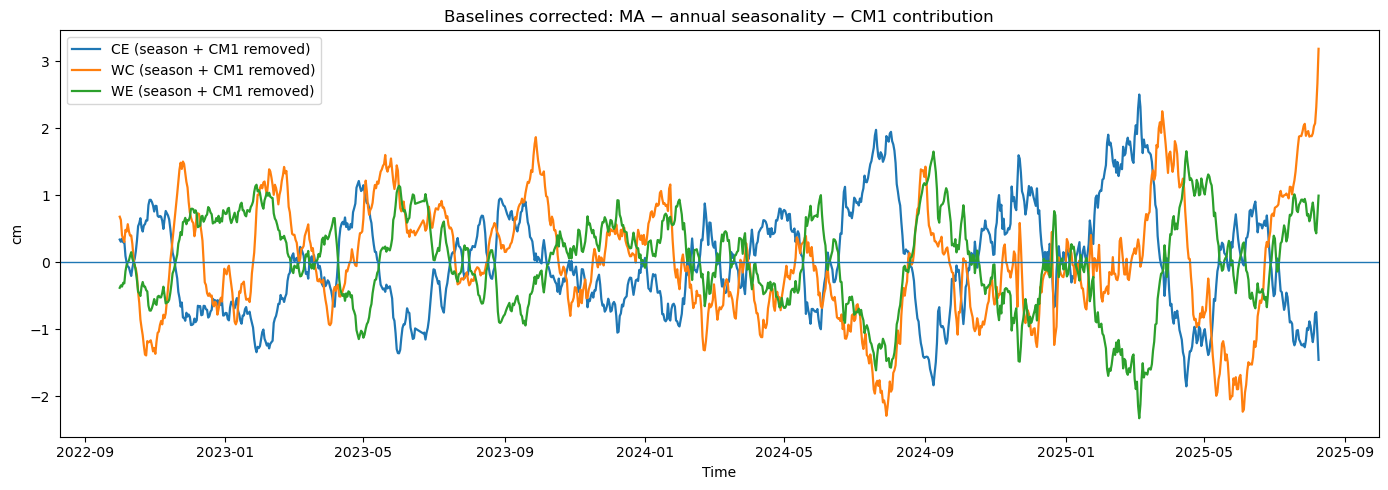

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User edits
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR  # rad/day

BASELINES = [
    ("CE", CE_FILE),
    ("WC", WC_FILE),
    ("WE", WE_FILE),
]

# -----------------------------
# Load baseline, daily resample
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

# -----------------------------
# Fit annual seasonality (sin/cos) + intercept + linear trend
# Return season(t), y_deseasoned, diagnostics
# -----------------------------
def fit_and_remove_annual_season(y_series, t0_common):
    y = y_series.to_numpy()
    t_days = (y_series.index - t0_common).total_seconds() / 86400.0

    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    # y = a + m*t + c*sin + d*cos
    A = np.column_stack([np.ones_like(t_days), t_days, sin_t, cos_t])
    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, m, c, d = x

    season = c * sin_t + d * cos_t
    y_deseason = y - season

    amp = float(np.sqrt(c * c + d * d))
    diag = {"amp_cm": amp, "peak_to_trough_cm": 2.0 * amp, "c": float(c), "d": float(d)}
    return pd.Series(season, index=y_series.index), pd.Series(y_deseason, index=y_series.index), diag

# -----------------------------
# CM1 via SVD on (T x N) matrix
# Returns:
#   cm1_score: (T,) time series (PC1 scores)
#   loadings : (N,) per-baseline loadings
#   var_expl : scalar variance explained by PC1
#   cm1_contrib: (T x N) CM1 contribution in each baseline's units
# -----------------------------
def common_mode_cm1(R):
    # Mean-center each baseline column
    R0 = R - R.mean(axis=0, keepdims=True)

    U, S, Vt = np.linalg.svd(R0, full_matrices=False)

    cm1_score = U[:, 0] * S[0]     # (T,)
    loadings = Vt[0, :]            # (N,)
    cm1_contrib = np.outer(cm1_score, loadings)  # (T x N), in baseline units
    var_expl = (S[0] ** 2) / np.sum(S ** 2)

    return cm1_score, loadings, var_expl, cm1_contrib

# ============================================================
# MAIN
# ============================================================
# Load + align
series = {name: load_baseline_daily_ma(path, name) for name, path in BASELINES}
df = pd.concat([series[n] for n, _ in BASELINES], axis=1).dropna()
t0_common = df.index[0]

baseline_names = [n for n, _ in BASELINES]

# Seasonality removal
season = pd.DataFrame(index=df.index)
deseason = pd.DataFrame(index=df.index)

for name in baseline_names:
    s, y_ds, diag = fit_and_remove_annual_season(df[name], t0_common)
    season[name] = s
    deseason[name] = y_ds
    print(f"\n==== {name} annual seasonality ====")
    print(f"Amplitude: {diag['amp_cm']:.4f} cm (peak-to-trough {diag['peak_to_trough_cm']:.4f} cm)")

# Common mode from seasonality-removed data (CM1 only)
R = deseason.to_numpy()  # (T x N)
cm1_score, loadings, var_expl, cm1_contrib = common_mode_cm1(R)

print("\n==== CM1 summary (from seasonality-removed data) ====")
print(f"Variance explained by CM1: {100*var_expl:.1f}%")
print("CM1 loadings:", dict(zip(baseline_names, loadings)))

# Corrected baselines: remove seasonality + CM1 contribution
corrected = pd.DataFrame(index=df.index)
for j, name in enumerate(baseline_names):
    corrected[name] = df[name] - season[name] - cm1_contrib[:, j]

# ============================================================
# PLOT 1: CM1 score time series
# ============================================================
plt.figure(figsize=(14, 4.5))
plt.plot(df.index, cm1_score, lw=2.0, label=f"CM1 score ({100*var_expl:.1f}% var)")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("CM1 score (PC units)")
plt.title("Common mode (CM1) from seasonality-removed baselines")
plt.legend()
plt.tight_layout()
plt.show()



# ============================================================
# PLOT 2: corrected baselines (seasonality + CM1 removed)
# ============================================================
plt.figure(figsize=(14, 5))
for name in baseline_names:
    plt.plot(corrected.index, corrected[name]-corrected[name].mean(), lw=1.6, label=f"{name} (season + CM1 removed)")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Baselines corrected: MA − annual seasonality − CM1 contribution")
plt.legend()
plt.tight_layout()
plt.show()


CE seasonal amp: 0.8563 cm (ptp 1.7125 cm)
WC seasonal amp: 1.1914 cm (ptp 2.3829 cm)
WE seasonal amp: 2.5315 cm (ptp 5.0629 cm)

CM_all (from season-removed, ALL baselines):
  variance explained: 98.4%
  loadings: {'CE': 0.6755356244794007, 'WC': 0.08175280605392397, 'WE': 0.7327810715087663}

CM_pair (from residuals, WC+WE only):
  variance explained: 68.5%
  loadings: {'WC': -0.903125516453686, 'WE': -0.4293766429724177}


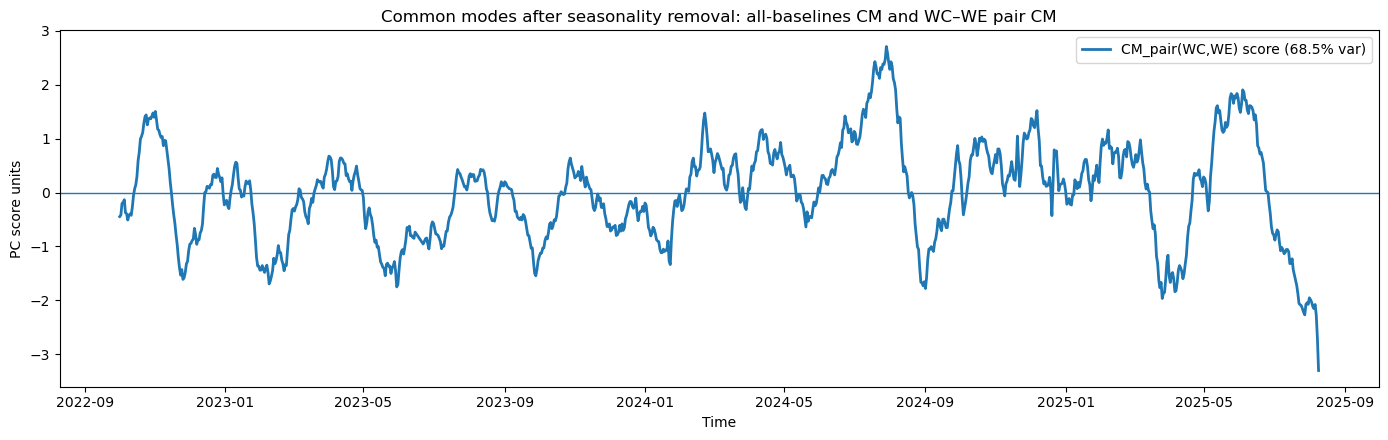

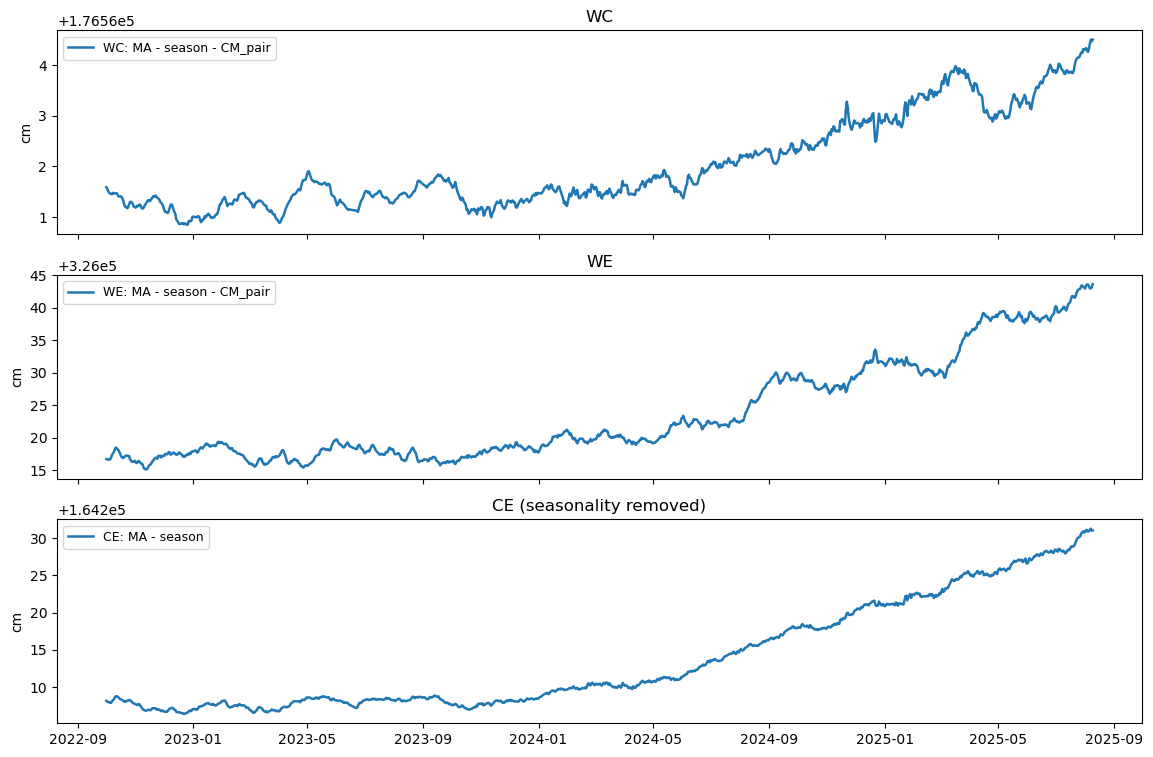

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User edits
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR  # rad/day

BASELINES = [
    ("CE", CE_FILE),
    ("WC", WC_FILE),
    ("WE", WE_FILE),
]

PAIR = ["WC", "WE"]  # common mode only between these two

# -----------------------------
# Load baseline, daily resample
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

# -----------------------------
# Fit annual seasonality (sin/cos) + intercept + linear trend
# Return season(t), y_deseasoned
# -----------------------------
def fit_and_remove_annual_season(y_series, t0_common):
    y = y_series.to_numpy()
    t_days = (y_series.index - t0_common).total_seconds() / 86400.0

    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    # y = a + m*t + c*sin + d*cos
    A = np.column_stack([np.ones_like(t_days), t_days, sin_t, cos_t])
    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, m, c, d = x

    season = c * sin_t + d * cos_t
    y_deseason = y - season

    amp = float(np.sqrt(c * c + d * d))
    return (pd.Series(season, index=y_series.index),
            pd.Series(y_deseason, index=y_series.index),
            {"amp_cm": amp, "ptp_cm": 2.0 * amp})

# -----------------------------
# CM1 via SVD on (T x N) matrix
# Returns:
#   score: (T,) PC1 score time series
#   loadings: (N,) per-column loadings
#   var_expl: scalar
#   contrib: (T x N) contribution in each column's units
# -----------------------------
def common_mode_cm1(R):
    R0 = R - R.mean(axis=0, keepdims=True)  # column mean-center
    U, S, Vt = np.linalg.svd(R0, full_matrices=False)
    score = U[:, 0] * S[0]
    loadings = Vt[0, :]
    contrib = np.outer(score, loadings)
    var_expl = (S[0] ** 2) / np.sum(S ** 2)
    return score, loadings, var_expl, contrib

# ============================================================
# MAIN
# ============================================================
# Load + align all three
series = {name: load_baseline_daily_ma(path, name) for name, path in BASELINES}
df = pd.concat([series[n] for n, _ in BASELINES], axis=1).dropna()
t0_common = df.index[0]
names_all = [n for n, _ in BASELINES]

# 1) Seasonality removal
season = pd.DataFrame(index=df.index)
deseason = pd.DataFrame(index=df.index)

for n in names_all:
    s, y_ds, diag = fit_and_remove_annual_season(df[n], t0_common)
    season[n] = s
    deseason[n] = y_ds
    print(f"{n} seasonal amp: {diag['amp_cm']:.4f} cm (ptp {diag['ptp_cm']:.4f} cm)")

# 2) Common mode across ALL baselines (CM_all)
R_all = deseason[names_all].to_numpy()
cm_all_score, cm_all_load, cm_all_var, cm_all_contrib = common_mode_cm1(R_all)

print("\nCM_all (from season-removed, ALL baselines):")
print(f"  variance explained: {100*cm_all_var:.1f}%")
print("  loadings:", dict(zip(names_all, cm_all_load)))

# Residual after removing seasonality + CM_all
res1 = pd.DataFrame(index=df.index)
for j, n in enumerate(names_all):
    res1[n] = df[n] - season[n] - cm_all_contrib[:, j]

# 3) Pairwise common mode between WE and WC on residuals
pair = PAIR
R_pair = res1[pair].to_numpy()  # (T x 2)
cm_pair_score, cm_pair_load, cm_pair_var, cm_pair_contrib = common_mode_cm1(R_pair)

print("\nCM_pair (from residuals, WC+WE only):")
print(f"  variance explained: {100*cm_pair_var:.1f}%")
print("  loadings:", dict(zip(pair, cm_pair_load)))

# Residual after removing pairwise CM from WC and WE only
res2 = res1.copy()
for j, n in enumerate(pair):
    res2[n] = df[n] - season[n] - cm_pair_contrib[:, j]

# ============================================================
# PLOTS
# ============================================================

# Plot A: CM_all and CM_pair scores together
plt.figure(figsize=(14, 4.5))
#plt.plot(df.index, cm_all_score, lw=2.0, label=f"CM_all score ({100*cm_all_var:.1f}% var)")
plt.plot(df.index, cm_pair_score, lw=2.0, label=f"CM_pair(WC,WE) score ({100*cm_pair_var:.1f}% var)")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("PC score units")
plt.title("Common modes after seasonality removal: all-baselines CM and WC–WE pair CM")
plt.legend()
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 1) WC (season + CM_all + CM_pair removed)
axes[0].plot(df.index, res2["WC"], lw=1.8, label="WC: MA - season - CM_pair")
axes[0].set_ylabel("cm")
axes[0].set_title("WC")
axes[0].legend(fontsize=9)

# 2) WE (season + CM_all + CM_pair removed)
axes[1].plot(df.index, res2["WE"], lw=1.8, label="WE: MA - season - CM_pair")

axes[1].set_ylabel("cm")
axes[1].set_title("WE")
axes[1].legend(fontsize=9)

# 3) CE (seasonality removed only)
axes[2].plot(df.index, deseason["CE"], lw=1.8, label="CE: MA - season")


axes[2].set_ylabel("cm")
axes[2].set_title("CE (seasonality removed)")
axes[2].legend(fontsize=9)



==== CE: fit y = a + b*Pc_z + c*sin + d*cos ====
b (Pc_z)     : -7.335868   (Pc included in fit, NOT removed)
Season amp   : 1.8951 cm (ptp 3.7902 cm)

==== WC: fit y = a + b*Pc_z + c*sin + d*cos ====
b (Pc_z)     : -0.826379   (Pc included in fit, NOT removed)
Season amp   : 1.3008 cm (ptp 2.6017 cm)

==== WE: fit y = a + b*Pc_z + c*sin + d*cos ====
b (Pc_z)     : -7.806333   (Pc included in fit, NOT removed)
Season amp   : 4.0243 cm (ptp 8.0485 cm)

CM_all (from season-removed, ALL baselines):
  variance explained: 98.4%
  loadings: {'CE': 0.6750156586362742, 'WC': 0.08176341190427001, 'WE': 0.7332588936178064}

CM_pair (from residuals, WC+WE only):
  variance explained: 68.7%
  loadings: {'WC': -0.9040222773195988, 'WE': -0.4274853472458282}


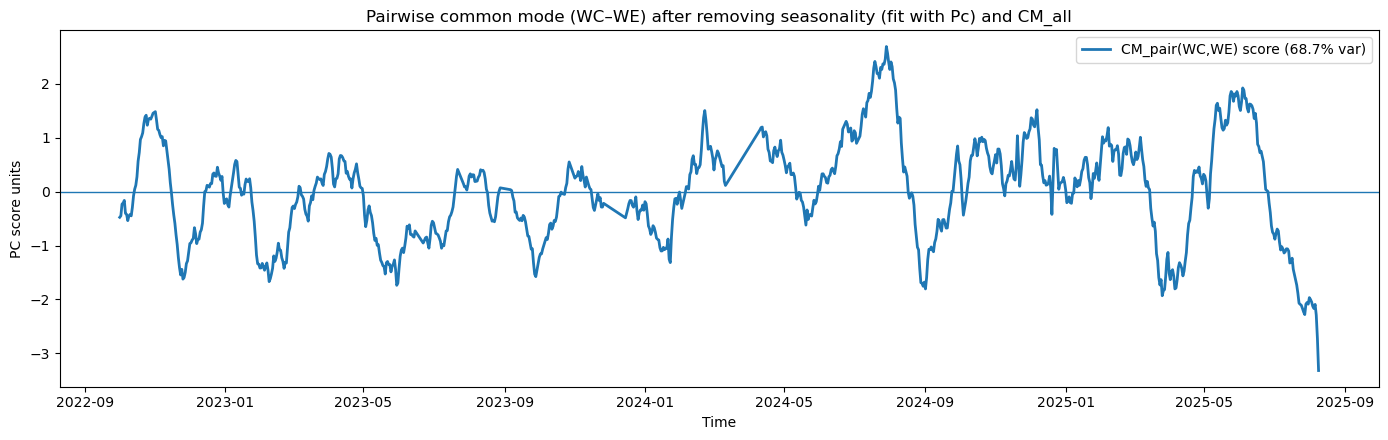

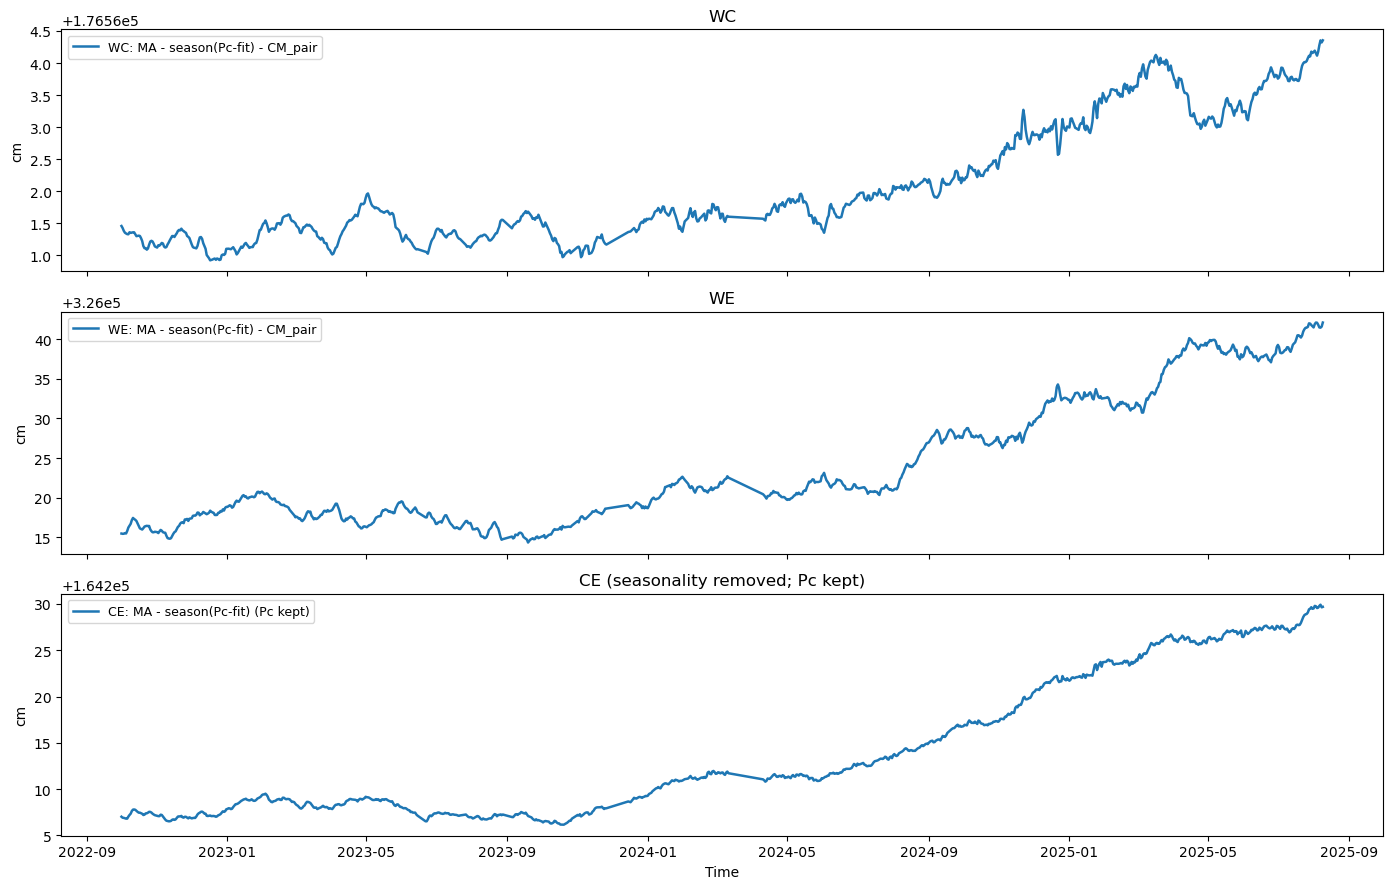

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User edits
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pc_drifcor.csv"          # <-- ADD Pc file

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR  # rad/day

BASELINES = [
    ("CE", CE_FILE),
    ("WC", WC_FILE),
    ("WE", WE_FILE),
]

PAIR = ["WC", "WE"]  # common mode only between these two

# -----------------------------
# Load baseline, daily resample
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

def load_pc_daily(path):
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")
    s = df.set_index("time")["pressure_kPa"].resample("1D").mean()
    s.name = "Pc_kPa"
    return s

# -----------------------------
# Fit Pc + annual seasonality (sin/cos) (+ intercept + linear trend)
# BUT remove ONLY the seasonal part (keep Pc effect)
# Model:
#   y = a b*Pc_z + c*sin + d*cos
# Returns: season_only(t), y_minus_season, diagnostics
# -----------------------------
def fit_pc_plus_annual_season_remove_only_season(y_series, pc_series, t0_common):
    y = y_series.to_numpy()

    # time in days from common start
    t_days = (y_series.index - t0_common).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    # Pc z-score on the aligned window
    Pc = pc_series.to_numpy()
    Pc_z = (Pc - Pc.mean()) / Pc.std()

    # Model WITHOUT linear trend:
    #   y = a + b*Pc_z + c*sin + d*cos
    A = np.column_stack([np.ones_like(t_days), Pc_z, sin_t, cos_t])
    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b, c, d = x

    season_only = c * sin_t + d * cos_t
    y_minus_season = y - season_only

    amp = float(np.sqrt(c * c + d * d))
    diag = {
        "a": float(a), "b": float(b), "c": float(c), "d": float(d),
        "amp_cm": amp, "ptp_cm": 2.0 * amp
    }
    return (pd.Series(season_only, index=y_series.index),
            pd.Series(y_minus_season, index=y_series.index),
            diag)

# -----------------------------
# CM1 via SVD on (T x N) matrix
# -----------------------------
def common_mode_cm1(R):
    R0 = R - R.mean(axis=0, keepdims=True)  # column mean-center
    U, S, Vt = np.linalg.svd(R0, full_matrices=False)
    score = U[:, 0] * S[0]
    loadings = Vt[0, :]
    contrib = np.outer(score, loadings)
    var_expl = (S[0] ** 2) / np.sum(S ** 2)
    return score, loadings, var_expl, contrib

# ============================================================
# MAIN
# ============================================================
# Load baselines
series = {name: load_baseline_daily_ma(path, name) for name, path in BASELINES}

# Load Pc
pc = load_pc_daily(PC_FILE)

# Align to a common daily window (requires CE, WC, WE, and Pc all present)
df = pd.concat([series[n] for n, _ in BASELINES] + [pc], axis=1).dropna()
t0_common = df.index[0]
names_all = [n for n, _ in BASELINES]

# 1) Seasonality removal (fit with Pc, remove ONLY seasonality)
season = pd.DataFrame(index=df.index)
deseason = pd.DataFrame(index=df.index)

for n in names_all:
    s_only, y_minus_season, diag = fit_pc_plus_annual_season_remove_only_season(
        y_series=df[n],
        pc_series=df["Pc_kPa"],
        t0_common=t0_common
    )
    season[n] = s_only
    deseason[n] = y_minus_season

    print(f"\n==== {n}: fit y = a + b*Pc_z + c*sin + d*cos ====")
    print(f"b (Pc_z)     : {diag['b']:.6f}   (Pc included in fit, NOT removed)")
    print(f"Season amp   : {diag['amp_cm']:.4f} cm (ptp {diag['ptp_cm']:.4f} cm)")

# 2) Common mode across ALL baselines (from season-removed)
R_all = deseason[names_all].to_numpy()
cm_all_score, cm_all_load, cm_all_var, cm_all_contrib = common_mode_cm1(R_all)

print("\nCM_all (from season-removed, ALL baselines):")
print(f"  variance explained: {100*cm_all_var:.1f}%")
print("  loadings:", dict(zip(names_all, cm_all_load)))

# Residual after removing seasonality + CM_all  (THIS STEP KEEPS YOUR WORKFLOW)
res1 = pd.DataFrame(index=df.index)
for j, n in enumerate(names_all):
    res1[n] = df[n] - season[n] - cm_all_contrib[:, j]

# 3) Pairwise common mode between WE and WC on residuals
pair = PAIR
R_pair = res1[pair].to_numpy()  # (T x 2)
cm_pair_score, cm_pair_load, cm_pair_var, cm_pair_contrib = common_mode_cm1(R_pair)

print("\nCM_pair (from residuals, WC+WE only):")
print(f"  variance explained: {100*cm_pair_var:.1f}%")
print("  loadings:", dict(zip(pair, cm_pair_load)))

# Residual after removing pairwise CM from WC and WE only
res2 = res1.copy()
for j, n in enumerate(pair):
    # IMPORTANT: your original line used df[...] again; keep the intended workflow:
    # remove CM_pair from res1 (which already removed season + CM_all)
    res2[n] = df[n] - season[n] - cm_pair_contrib[:, j]

# ============================================================
# PLOTS
# ============================================================

# Plot A: pair common mode score (as you had)
plt.figure(figsize=(14, 4.5))
plt.plot(df.index, cm_pair_score, lw=2.0, label=f"CM_pair(WC,WE) score ({100*cm_pair_var:.1f}% var)")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("PC score units")
plt.title("Pairwise common mode (WC–WE) after removing seasonality (fit with Pc) and CM_all")
plt.legend()
plt.tight_layout()
plt.show()

# Plot B: 3 subplots (WC, WE corrected; CE seasonality removed only)
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df.index, res2["WC"], lw=1.8, label="WC: MA - season(Pc-fit) - CM_pair")
axes[0].set_ylabel("cm")
axes[0].set_title("WC")
axes[0].legend(fontsize=9)

axes[1].plot(df.index, res2["WE"], lw=1.8, label="WE: MA - season(Pc-fit) - CM_pair")
axes[1].set_ylabel("cm")
axes[1].set_title("WE")
axes[1].legend(fontsize=9)

axes[2].plot(df.index, deseason["CE"], lw=1.8, label="CE: MA - season(Pc-fit) (Pc kept)")
axes[2].set_ylabel("cm")
axes[2].set_title("CE (seasonality removed; Pc kept)")
axes[2].legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


CE: seasonal amp=0.8563 cm (ptp=1.7125 cm)
WC: seasonal amp=1.1914 cm (ptp=2.3829 cm)
WE: seasonal amp=2.5315 cm (ptp=5.0629 cm)


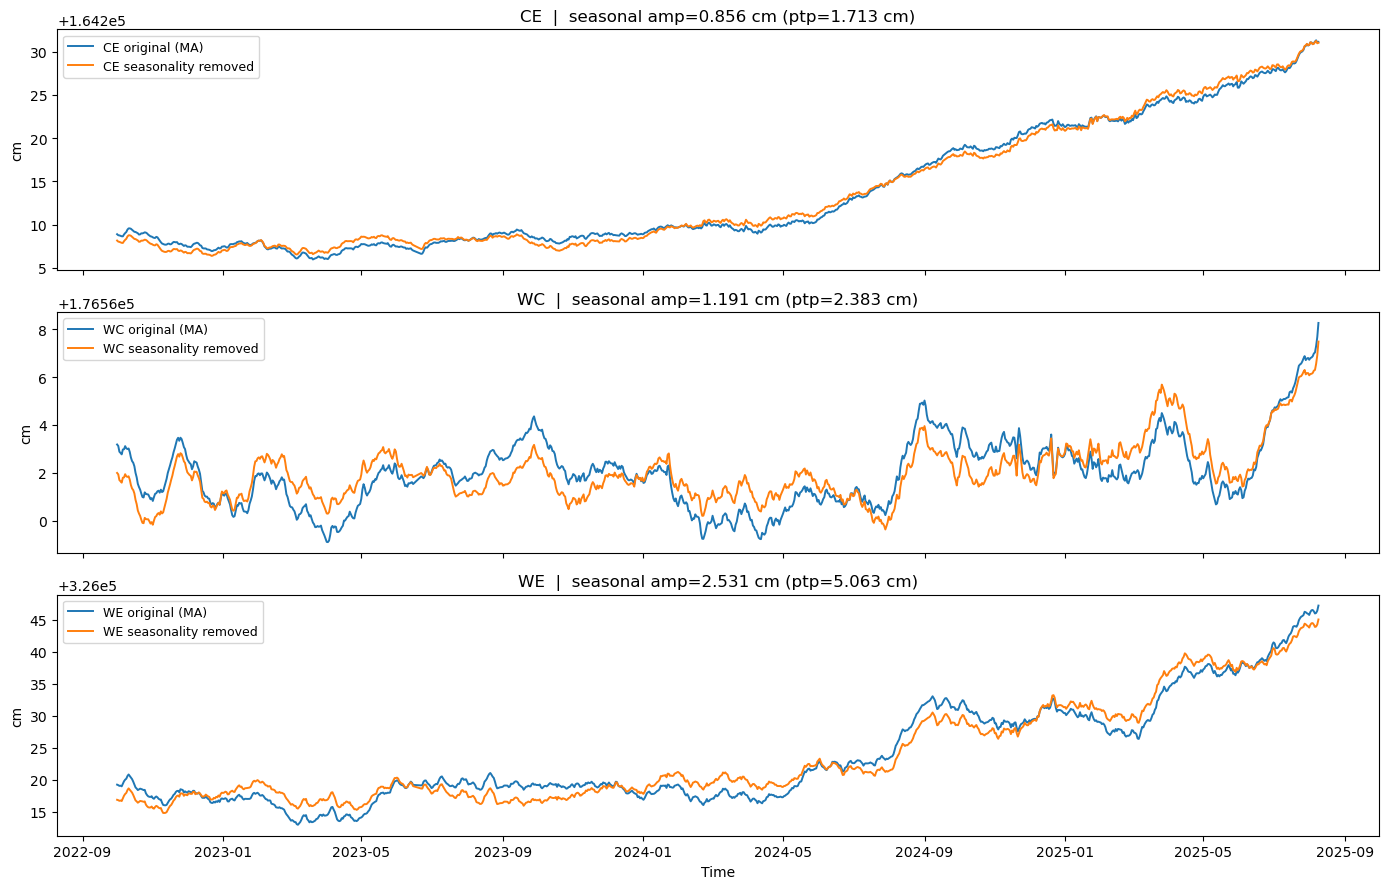

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User edits
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR  # rad/day

BASELINES = [
    ("CE", CE_FILE),
    ("WC", WC_FILE),
    ("WE", WE_FILE),
]

# -----------------------------
# Load baseline, daily resample
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

# -----------------------------
# Fit annual seasonality (sin/cos) + intercept + linear trend
# Return season(t), y_deseasoned, diagnostics
# -----------------------------
def fit_annual_season(y_series, t0_common):
    y = y_series.to_numpy()
    t_days = (y_series.index - t0_common).total_seconds() / 86400.0

    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    # y = a + m*t + c*sin + d*cos
    A = np.column_stack([np.ones_like(t_days), t_days, sin_t, cos_t])
    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, m, c, d = x

    season = c * sin_t + d * cos_t
    y_deseason = y - season

    amp = float(np.sqrt(c * c + d * d))
    diag = {"a": float(a), "m": float(m), "c": float(c), "d": float(d),
            "amp_cm": amp, "ptp_cm": 2.0 * amp}

    return (pd.Series(season, index=y_series.index, name=y_series.name + "_season"),
            pd.Series(y_deseason, index=y_series.index, name=y_series.name + "_deseason"),
            diag)

# ============================================================
# MAIN
# ============================================================
# Load + align all three to common time support
series = {name: load_baseline_daily_ma(path, name) for name, path in BASELINES}
df = pd.concat([series[name] for name, _ in BASELINES], axis=1).dropna()
t0_common = df.index[0]
names = [n for n, _ in BASELINES]

# Seasonality fit/removal
season = pd.DataFrame(index=df.index)
deseason = pd.DataFrame(index=df.index)
diags = {}

for n in names:
    s, y_ds, diag = fit_annual_season(df[n], t0_common)
    season[n] = s
    deseason[n] = y_ds
    diags[n] = diag
    print(f"{n}: seasonal amp={diag['amp_cm']:.4f} cm (ptp={diag['ptp_cm']:.4f} cm)")

# ============================================================
# PLOTS: 3 subplots (one per baseline)
# Each subplot shows: original, seasonal signal, seasonality-removed
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, n in zip(axes, names):
    ax.plot(df.index, df[n], lw=1.4, label=f"{n} original (MA)")
    #ax.plot(df.index, season[n], lw=1.6, label=f"{n} seasonal signal")
    ax.plot(df.index, deseason[n], lw=1.4, label=f"{n} seasonality removed")

    ax.set_title(f"{n}  |  seasonal amp={diags[n]['amp_cm']:.3f} cm (ptp={diags[n]['ptp_cm']:.3f} cm)")
    ax.set_ylabel("cm")
    #ax.axhline(0, lw=1)

    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


CE: seasonal amp = 1.8951 cm (ptp 3.7902 cm), b(Pc_z)=-7.335868
WC: seasonal amp = 1.3008 cm (ptp 2.6017 cm), b(Pc_z)=-0.826379
WE: seasonal amp = 4.0243 cm (ptp 8.0485 cm), b(Pc_z)=-7.806333


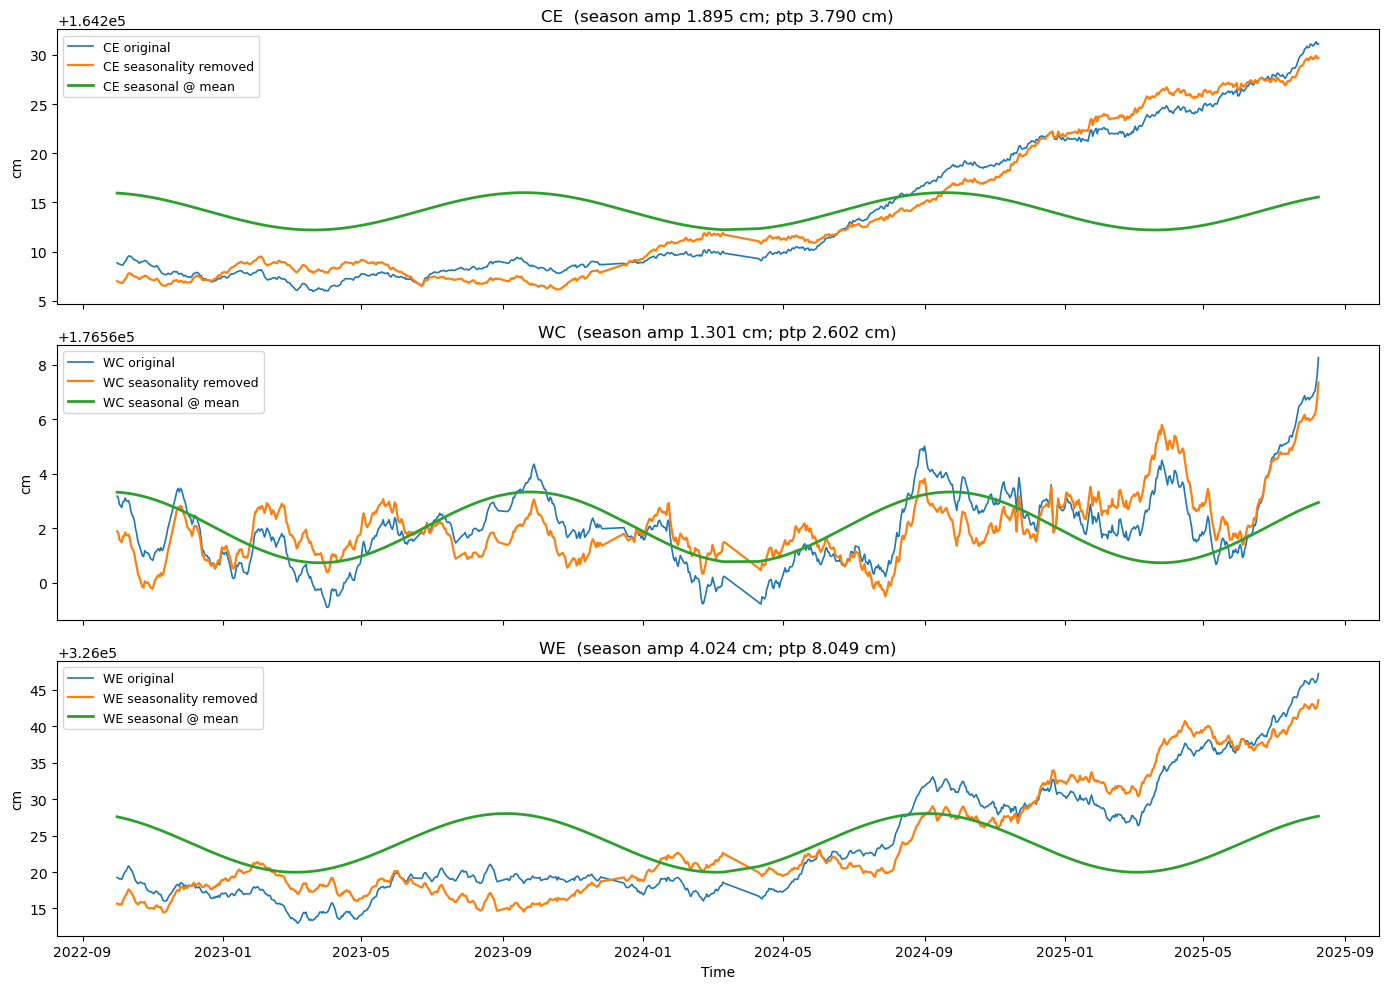

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Files / settings
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pc_drifcor.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR  # rad/day

BASELINES = [
    ("CE", CE_FILE),
    ("WC", WC_FILE),
    ("WE", WE_FILE),
]

# -----------------------------
# Load baseline, daily resample
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

def load_pc_daily(path):
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")
    s = df.set_index("time")["pressure_kPa"].resample("1D").mean()
    s.name = "Pc_kPa"
    return s

# -----------------------------
# Fit: y = a + b*Pc_z + c*sin + d*cos
# Remove ONLY seasonal part (keep Pc effect in y_minus_season)
# -----------------------------
def fit_pc_plus_annual_season_remove_only_season(y_series, pc_series, t0_common):
    y = y_series.to_numpy()

    t_days = (y_series.index - t0_common).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    Pc = pc_series.to_numpy()
    Pc_z = (Pc - Pc.mean()) / Pc.std()

    A = np.column_stack([np.ones_like(t_days), Pc_z, sin_t, cos_t])
    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b, c, d = x

    season_only = c * sin_t + d * cos_t
    y_minus_season = y - season_only

    amp = float(np.sqrt(c * c + d * d))
    diag = {"a": float(a), "b": float(b), "c": float(c), "d": float(d),
            "amp_cm": amp, "ptp_cm": 2.0 * amp}
    return (pd.Series(season_only, index=y_series.index),
            pd.Series(y_minus_season, index=y_series.index),
            diag)

# ============================================================
# MAIN
# ============================================================
series = {name: load_baseline_daily_ma(path, name) for name, path in BASELINES}
pc = load_pc_daily(PC_FILE)

# Align to common daily window (all baselines + Pc)
df = pd.concat([series[n] for n, _ in BASELINES] + [pc], axis=1).dropna()
t0_common = df.index[0]
names = [n for n, _ in BASELINES]

season = pd.DataFrame(index=df.index)
deseason = pd.DataFrame(index=df.index)
diag = {}

for n in names:
    s_only, y_minus_season, d = fit_pc_plus_annual_season_remove_only_season(
        y_series=df[n],
        pc_series=df["Pc_kPa"],
        t0_common=t0_common
    )
    season[n] = s_only
    deseason[n] = y_minus_season
    diag[n] = d
    print(f"{n}: seasonal amp = {d['amp_cm']:.4f} cm (ptp {d['ptp_cm']:.4f} cm), b(Pc_z)={d['b']:.6f}")

# ============================================================
# PLOTS (3 subplots; each shows original, deseasoned, and mean-offset seasonal)
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, n in zip(axes, names):
    y = df[n]
    y_ds = deseason[n]
    s = season[n]

    mean_y = float(y.mean())
    s_at_mean = mean_y + s  # <-- key: seasonal component plotted around baseline mean

    ax.plot(df.index, y, lw=1.2, label=f"{n} original")
    ax.plot(df.index, y_ds, lw=1.6, label=f"{n} seasonality removed")
    ax.plot(df.index, s_at_mean, lw=2.0, label=f"{n} seasonal @ mean")

    ax.set_ylabel("cm")
    ax.set_title(f"{n}  (season amp {diag[n]['amp_cm']:.3f} cm; ptp {diag[n]['ptp_cm']:.3f} cm)")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


CE: m = 0.021914 cm/day | seasonal amp = 0.8563 cm (ptp 1.7125 cm)
WC: m = 0.002237 cm/day | seasonal amp = 1.1914 cm (ptp 2.3829 cm)
WE: m = 0.022983 cm/day | seasonal amp = 2.5315 cm (ptp 5.0629 cm)


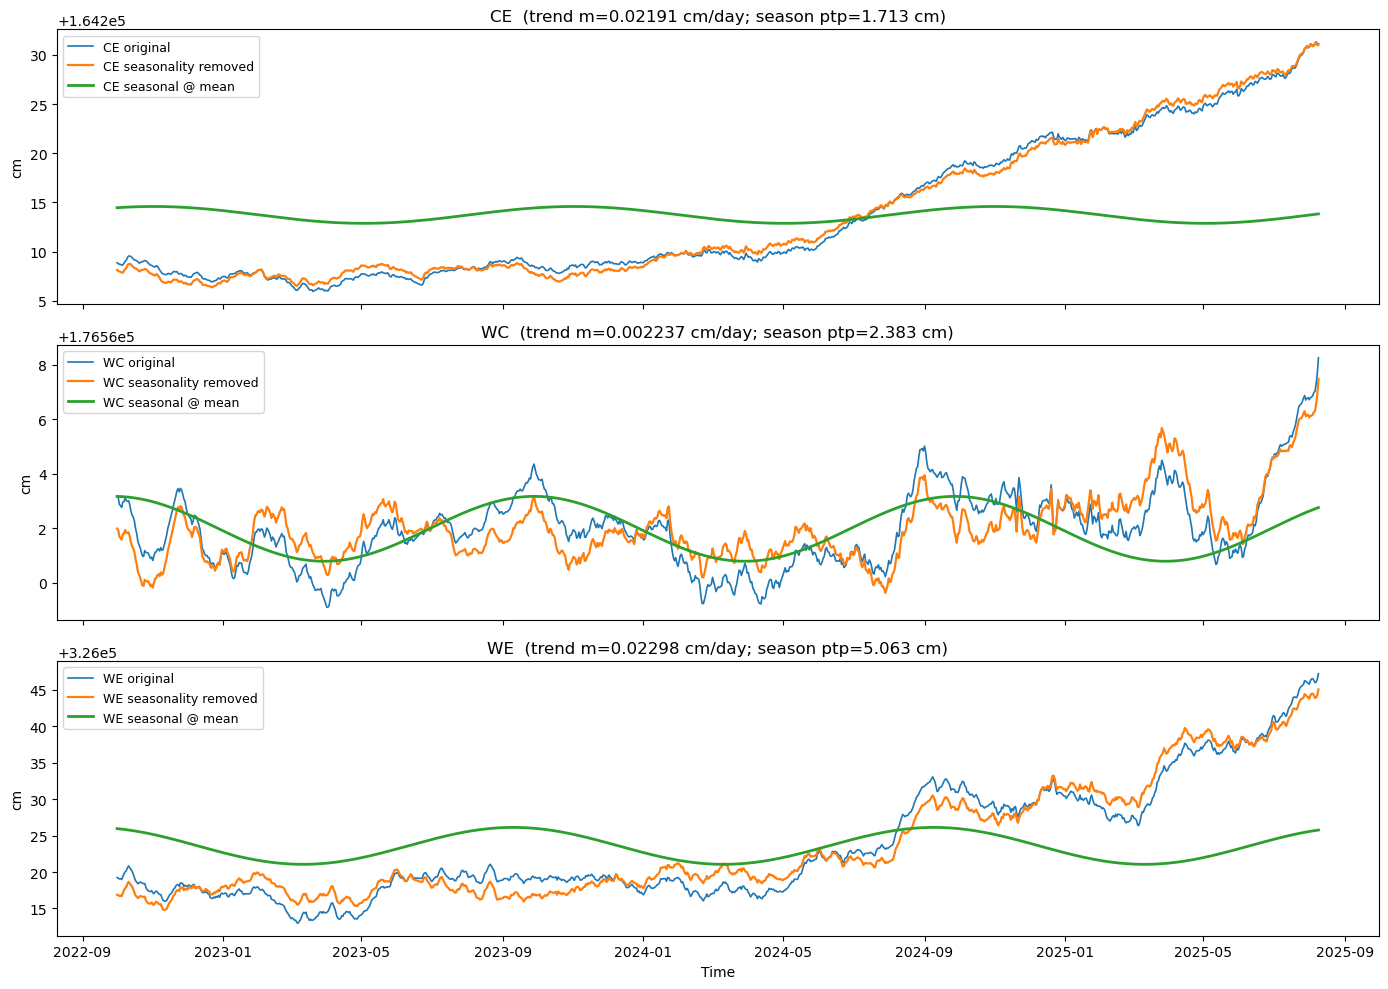

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Files / settings
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR  # rad/day

BASELINES = [
    ("CE", CE_FILE),
    ("WC", WC_FILE),
    ("WE", WE_FILE),
]

# -----------------------------
# Load baseline, daily resample
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

# -----------------------------
# Seasonal model:
#   y = a + m*t + c*sin + d*cos
# Remove ONLY the seasonal part (keep intercept+trend in deseasoned)
# Returns: season_only(t), y_minus_season, diagnostics
# -----------------------------
def fit_trend_plus_annual_season_remove_only_season(y_series, t0_common):
    y = y_series.to_numpy()

    # time in days from common start
    t_days = (y_series.index - t0_common).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    # Model: y = a + m*t + c*sin + d*cos
    A = np.column_stack([np.ones_like(t_days), t_days, sin_t, cos_t])
    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, m, c, d = x

    season_only = c * sin_t + d * cos_t
    y_minus_season = y - season_only

    amp = float(np.sqrt(c * c + d * d))
    diag = {
        "a": float(a), "m": float(m), "c": float(c), "d": float(d),
        "amp_cm": amp, "ptp_cm": 2.0 * amp
    }
    return (pd.Series(season_only, index=y_series.index),
            pd.Series(y_minus_season, index=y_series.index),
            diag)

# ============================================================
# MAIN
# ============================================================
series = {name: load_baseline_daily_ma(path, name) for name, path in BASELINES}

# Align baselines to common daily window
df = pd.concat([series[n] for n, _ in BASELINES], axis=1).dropna()
t0_common = df.index[0]
names = [n for n, _ in BASELINES]

season = pd.DataFrame(index=df.index)
deseason = pd.DataFrame(index=df.index)
diag = {}

for n in names:
    s_only, y_minus_season, d = fit_trend_plus_annual_season_remove_only_season(
        y_series=df[n],
        t0_common=t0_common
    )
    season[n] = s_only
    deseason[n] = y_minus_season
    diag[n] = d
    print(f"{n}: m = {d['m']:.6f} cm/day | seasonal amp = {d['amp_cm']:.4f} cm (ptp {d['ptp_cm']:.4f} cm)")

# ============================================================
# PLOTS (3 subplots; each shows original, deseasoned, and mean-offset seasonal)
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, n in zip(axes, names):
    y = df[n]
    y_ds = deseason[n]
    s = season[n]

    mean_y = float(y.mean())
    s_at_mean = mean_y + s  # seasonal component plotted around baseline mean

    ax.plot(df.index, y, lw=1.2, label=f"{n} original")
    ax.plot(df.index, y_ds, lw=1.6, label=f"{n} seasonality removed")
    ax.plot(df.index, s_at_mean, lw=2.0, label=f"{n} seasonal @ mean")

    ax.set_ylabel("cm")
    ax.set_title(f"{n}  (trend m={diag[n]['m']:.4g} cm/day; season ptp={diag[n]['ptp_cm']:.3f} cm)")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


In [44]:
t_days = (df.index - df.index[0]).total_seconds() / 86400.0
sin_t = np.sin(W * t_days)
cos_t = np.cos(W * t_days)

Pc = df["Pc_kPa"].to_numpy()
Pc_z = (Pc - Pc.mean()) / Pc.std()

print("corr(Pc_z, sin):", np.corrcoef(Pc_z, sin_t)[0,1])
print("corr(Pc_z, cos):", np.corrcoef(Pc_z, cos_t)[0,1])
print("corr(Pc_z, t)  :", np.corrcoef(Pc_z, t_days)[0,1])


corr(Pc_z, sin): 0.13279444648198022
corr(Pc_z, cos): 0.20462351913698257
corr(Pc_z, t)  : -0.9177212437372354


In [45]:
def vif_cols(X):
    # X: (T x p) numpy array, columns are predictors
    # returns VIF for each column
    vifs = []
    for j in range(X.shape[1]):
        yj = X[:, j]
        Xo = np.delete(X, j, axis=1)
        beta, *_ = np.linalg.lstsq(Xo, yj, rcond=None)
        yhat = Xo @ beta
        ssr = np.sum((yj - yhat)**2)
        sst = np.sum((yj - np.mean(yj))**2)
        r2 = 1 - ssr/sst if sst > 0 else np.nan
        vifs.append(1/(1-r2) if r2 < 1 else np.inf)
    return vifs

X = np.column_stack([Pc_z, sin_t, cos_t, t_days])
labels = ["Pc_z", "sin", "cos", "t_days"]
for lab, v in zip(labels, vif_cols(X)):
    print(lab, "VIF =", v)


Pc_z VIF = 1.3294758672533586
sin VIF = 1.0211395174514513
cos VIF = 1.0398935881366433
t_days VIF = 0.32970882784449784


Original columns used:
  CE: Distance (cm)
  WC: Distance (cm)
  WE: Distance (cm)
CE seasonal amp: 0.8563 cm (ptp 1.7125 cm)
WC seasonal amp: 1.1914 cm (ptp 2.3829 cm)
WE seasonal amp: 2.5315 cm (ptp 5.0629 cm)

CM_all (from season-removed, ALL baselines):
  variance explained: 98.4%
  loadings: {'CE': 0.6755356244794007, 'WC': 0.08175280605392397, 'WE': 0.7327810715087663}

CM_pair (from residuals, WC+WE only):
  variance explained: 68.5%
  loadings: {'WC': -0.903125516453686, 'WE': -0.4293766429724177}


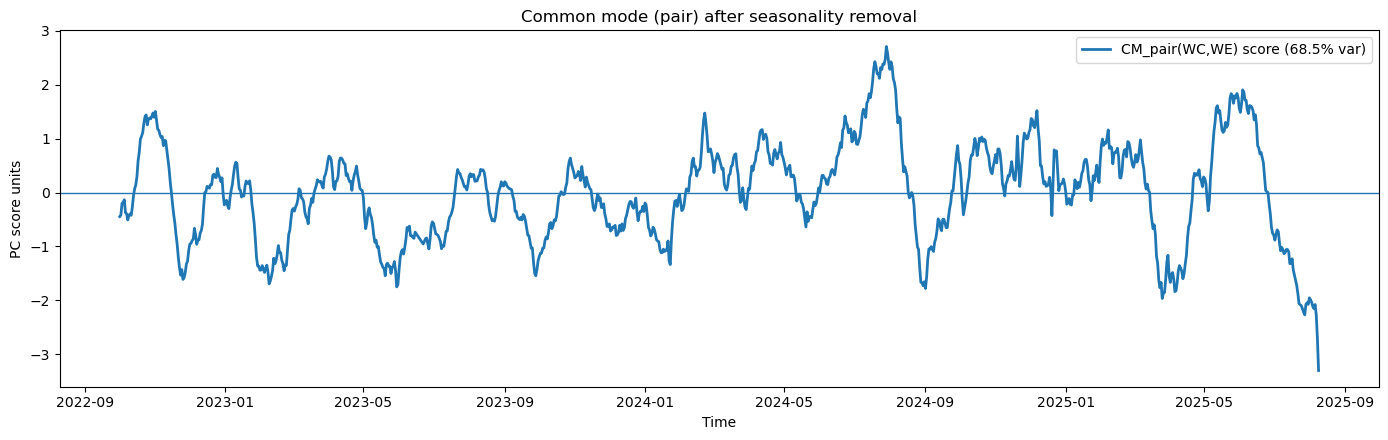

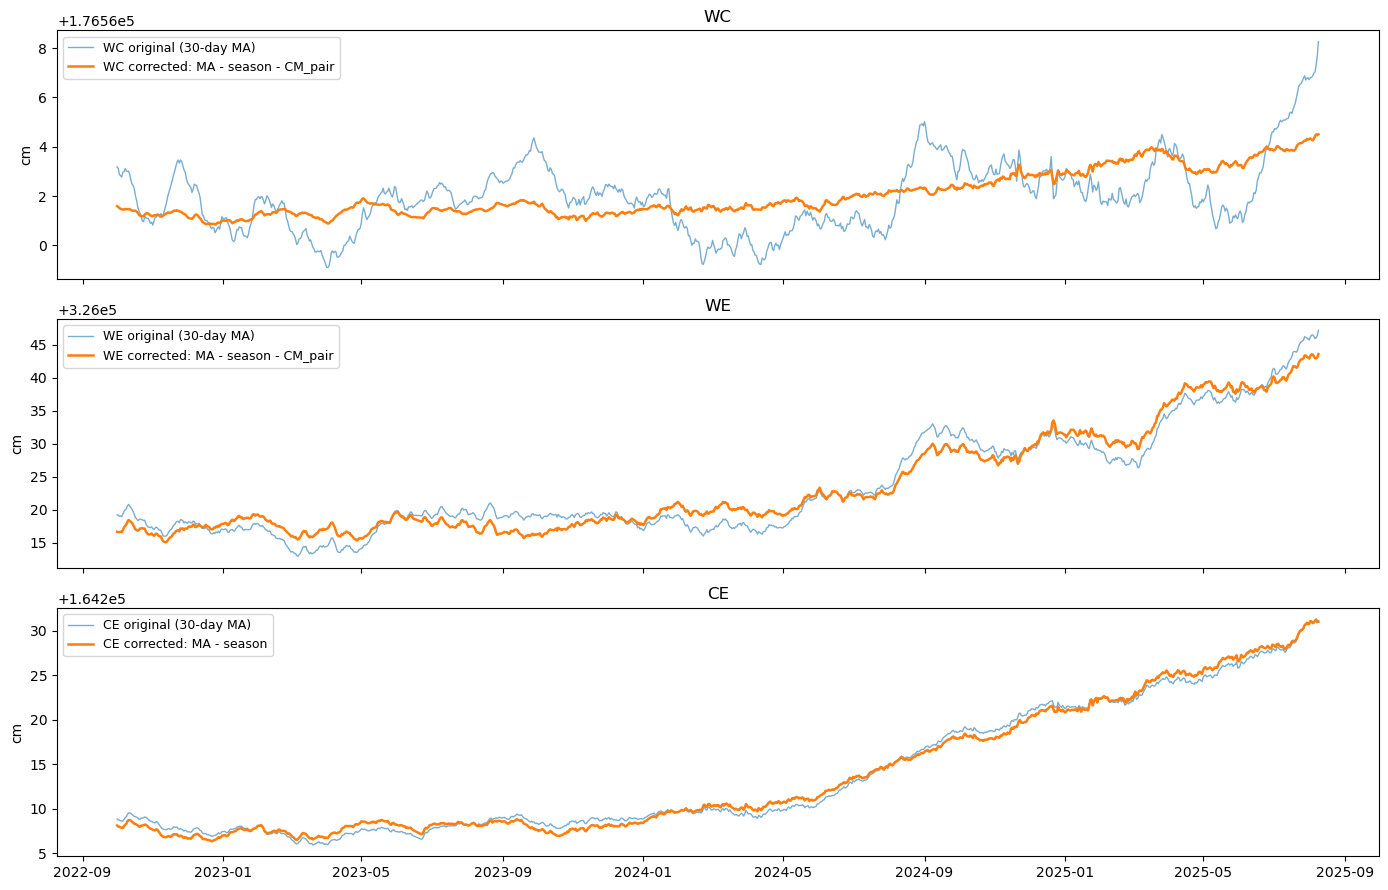

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User edits
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR  # rad/day

BASELINES = [
    ("CE", CE_FILE),
    ("WC", WC_FILE),
    ("WE", WE_FILE),
]

PAIR = ["WC", "WE"]  # common mode only between these two

# -----------------------------
# Helpers: choose original column
# -----------------------------
def pick_original_column(df):
    """
    Try to pick the "original" (non-moving-average) baseline distance column.
    Falls back to the first numeric column if nothing obvious is found.
    """
    preferred = [
        "Distance (cm)", "Distance(cm)", "Distance", "distance",
        "Range (cm)", "range_cm", "range",
        "Value (cm)", "value_cm", "value",
    ]
    for c in preferred:
        if c in df.columns:
            return c

    # Otherwise, pick first numeric column that's not time or moving average-ish
    candidates = []
    for c in df.columns:
        cl = c.lower()
        if "record time" in cl or "time" == cl:
            continue
        if "moving average" in cl or "ma" == cl:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            candidates.append(c)

    if len(candidates) == 0:
        raise ValueError("Could not find a numeric 'original baseline' column in the CSV.")
    return candidates[0]

# -----------------------------
# Load baseline: original (no MA), daily mean
# -----------------------------
def load_baseline_daily_original(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    col = pick_original_column(df)
    s = df.set_index("Record Time")[col].resample("1D").mean()
    s.name = name
    return s, col  # also return which column we used

# -----------------------------
# Load baseline, daily resample (Moving Average)
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

# -----------------------------
# Fit annual seasonality (sin/cos) + intercept + linear trend
# Return season(t), y_deseasoned
# -----------------------------
def fit_and_remove_annual_season(y_series, t0_common):
    y = y_series.to_numpy()
    t_days = (y_series.index - t0_common).total_seconds() / 86400.0

    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    # y = a + m*t + c*sin + d*cos
    A = np.column_stack([np.ones_like(t_days), t_days, sin_t, cos_t])
    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, m, c, d = x

    season = c * sin_t + d * cos_t
    y_deseason = y - season

    amp = float(np.sqrt(c * c + d * d))
    return (pd.Series(season, index=y_series.index),
            pd.Series(y_deseason, index=y_series.index),
            {"amp_cm": amp, "ptp_cm": 2.0 * amp})

# -----------------------------
# CM1 via SVD on (T x N) matrix
# -----------------------------
def common_mode_cm1(R):
    R0 = R - R.mean(axis=0, keepdims=True)  # column mean-center
    U, S, Vt = np.linalg.svd(R0, full_matrices=False)
    score = U[:, 0] * S[0]
    loadings = Vt[0, :]
    contrib = np.outer(score, loadings)
    var_expl = (S[0] ** 2) / np.sum(S ** 2)
    return score, loadings, var_expl, contrib

# ============================================================
# MAIN
# ============================================================

# Load MA (corrected) series (these are what you already use)
series_ma = {name: load_baseline_daily_ma(path, name) for name, path in BASELINES}
df = pd.concat([series_ma[n] for n, _ in BASELINES], axis=1).dropna()

# Load ORIGINAL (non-MA) series and align to same time window as df
series_orig = {}
orig_cols_used = {}
for name, path in BASELINES:
    s_orig, col_used = load_baseline_daily_original(path, name)
    series_orig[name] = s_orig
    orig_cols_used[name] = col_used

df_orig = pd.concat([series_orig[n] for n, _ in BASELINES], axis=1)

# Align originals to the corrected timeframe
df_orig = df_orig.reindex(df.index).dropna()

# Make sure corrected df matches originals (common index)
common_index = df.index.intersection(df_orig.index)
df = df.loc[common_index].copy()
df_orig = df_orig.loc[common_index].copy()

t0_common = df.index[0]
names_all = [n for n, _ in BASELINES]

print("Original columns used:")
for n in names_all:
    print(f"  {n}: {orig_cols_used[n]}")

# 1) Seasonality removal (from corrected/MA series)
season = pd.DataFrame(index=df.index)
deseason = pd.DataFrame(index=df.index)

for n in names_all:
    s, y_ds, diag = fit_and_remove_annual_season(df[n], t0_common)
    season[n] = s
    deseason[n] = y_ds
    print(f"{n} seasonal amp: {diag['amp_cm']:.4f} cm (ptp {diag['ptp_cm']:.4f} cm)")

# 2) Common mode across ALL baselines (CM_all)
R_all = deseason[names_all].to_numpy()
cm_all_score, cm_all_load, cm_all_var, cm_all_contrib = common_mode_cm1(R_all)

print("\nCM_all (from season-removed, ALL baselines):")
print(f"  variance explained: {100*cm_all_var:.1f}%")
print("  loadings:", dict(zip(names_all, cm_all_load)))

# Residual after removing seasonality + CM_all
res1 = pd.DataFrame(index=df.index)
for j, n in enumerate(names_all):
    res1[n] = df[n] - season[n] - cm_all_contrib[:, j]

# 3) Pairwise common mode between WE and WC on residuals
pair = PAIR
R_pair = res1[pair].to_numpy()
cm_pair_score, cm_pair_load, cm_pair_var, cm_pair_contrib = common_mode_cm1(R_pair)

print("\nCM_pair (from residuals, WC+WE only):")
print(f"  variance explained: {100*cm_pair_var:.1f}%")
print("  loadings:", dict(zip(pair, cm_pair_load)))

# Residual after removing pairwise CM from WC and WE only
# (CE stays as deseason only, same as you had)
res2 = res1.copy()
for j, n in enumerate(pair):
    res2[n] = df[n] - season[n] - cm_pair_contrib[:, j]

# ============================================================
# PLOTS
# ============================================================

# Plot A: CM_pair score
plt.figure(figsize=(14, 4.5))
plt.plot(df.index, cm_pair_score, lw=2.0, label=f"CM_pair(WC,WE) score ({100*cm_pair_var:.1f}% var)")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("PC score units")
plt.title("Common mode (pair) after seasonality removal")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# PLOTS (overlay ORIGINAL 30-day MA on top of corrected)
#   "original" = df[...]  (the 30-day moving average BEFORE removing anything)
#   "corrected" = res2[...] or deseason["CE"]
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 1) WC
axes[0].plot(df.index, df["WC"], lw=1.0, alpha=0.6, label="WC original (30-day MA)")
axes[0].plot(df.index, res2["WC"], lw=1.8, label="WC corrected: MA - season - CM_pair")
axes[0].set_ylabel("cm")
axes[0].set_title("WC")
axes[0].legend(fontsize=9)

# 2) WE
axes[1].plot(df.index, df["WE"], lw=1.0, alpha=0.6, label="WE original (30-day MA)")
axes[1].plot(df.index, res2["WE"], lw=1.8, label="WE corrected: MA - season - CM_pair")
axes[1].set_ylabel("cm")
axes[1].set_title("WE")
axes[1].legend(fontsize=9)

# 3) CE
axes[2].plot(df.index, df["CE"], lw=1.0, alpha=0.6, label="CE original (30-day MA)")
axes[2].plot(df.index, deseason["CE"], lw=1.8, label="CE corrected: MA - season")
axes[2].set_ylabel("cm")
axes[2].set_title("CE")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()
